<a href="https://colab.research.google.com/github/SANDULFERNANDO/Stellarx-Diagnostic-System/blob/feature%2FResNet50-Model/ResNet50Model_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import os
import json
import random

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

In [5]:
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

In [6]:
DATASET_PATH = "/content/drive/MyDrive/dataset"

TRAIN_DIR = os.path.join(DATASET_PATH, "Train")
VALIDATION_DIR = os.path.join(DATASET_PATH, "Validation")
TEST_DIR = os.path.join(DATASET_PATH, "Test")

In [7]:
OUTPUT_DIR = "/content/drive/MyDrive/ResNet50_Model3"

os.makedirs(OUTPUT_DIR, exist_ok=True)

In [8]:
IMAGE_SIZE = (224, 224)

BATCH_SIZE = 32

NUM_CLASSES = 3

FROZEN_EPOCHS = 15

FINE_TUNE_EPOCHS = 15

INITIAL_LEARNING_RATE = 1e-4

FINE_TUNE_LEARNING_RATE = 1e-5

FINE_TUNE_FROM_LAYER = 140

DROPOUT_RATE = 0.30

AUTOTUNE = tf.data.AUTOTUNE

In [9]:
train_dataset = tf.keras.utils.image_dataset_from_directory(

    TRAIN_DIR,

    image_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    label_mode="categorical",

    shuffle=True,

    seed=RANDOM_SEED

)

Found 2680 files belonging to 3 classes.


In [10]:
validation_dataset = tf.keras.utils.image_dataset_from_directory(

    VALIDATION_DIR,

    image_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    label_mode="categorical",

    shuffle=False

)

Found 574 files belonging to 3 classes.


In [11]:
test_dataset = tf.keras.utils.image_dataset_from_directory(

    TEST_DIR,

    image_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    label_mode="categorical",

    shuffle=False

)

Found 573 files belonging to 3 classes.


In [12]:
class_names = train_dataset.class_names

print(class_names)

with open(
    os.path.join(OUTPUT_DIR, "class_names3.json"),
    "w"
) as f:

    json.dump(
        {
            i: name
            for i, name in enumerate(class_names)
        },
        f,
        indent=4
    )

['Eczema', 'Leishmaniasis', 'Tinea']


In [13]:
train_dataset = train_dataset.prefetch(AUTOTUNE)

validation_dataset = validation_dataset.prefetch(AUTOTUNE)

test_dataset = test_dataset.prefetch(AUTOTUNE)

In [14]:
training_labels = []

for class_index, class_name in enumerate(class_names):

    image_count = len(
        os.listdir(
            os.path.join(TRAIN_DIR, class_name)
        )
    )

    training_labels.extend(
        [class_index] * image_count
    )

training_labels = np.array(training_labels)

weights = compute_class_weight(

    class_weight="balanced",

    classes=np.arange(NUM_CLASSES),

    y=training_labels

)

class_weights = {

    i: float(weight)

    for i, weight in enumerate(weights)

}

print(class_weights)

{0: 0.826395312981807, 1: 1.7048346055979644, 2: 0.8310077519379845}


In [15]:
data_augmentation = tf.keras.Sequential([

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.03),

    layers.RandomZoom(0.10),

    layers.RandomContrast(0.10)

])

In [16]:
base_model = ResNet50(

    weights="imagenet",

    include_top=False,

    input_shape=(224, 224, 3)

)

base_model.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [17]:
inputs = tf.keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)

x = preprocess_input(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(DROPOUT_RATE)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model = tf.keras.Model(inputs, outputs)

In [18]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ sequential[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 3)         │      6,147 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,593,859 (90.00 MB)

 Trainable params: 6,147 (24.01 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [19]:
model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=INITIAL_LEARNING_RATE
    ),

    loss="categorical_crossentropy",

    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]

)

In [20]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(

    filepath=os.path.join(
        OUTPUT_DIR,
        "best_resnet50.keras"
    ),

    monitor="val_accuracy",

    save_best_only=True,

    mode="max",

    verbose=1

)

early_stop = tf.keras.callbacks.EarlyStopping(

    monitor="val_loss",

    patience=5,

    restore_best_weights=True,

    verbose=1

)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=2,

    min_lr=1e-7,

    verbose=1

)

csv_logger = tf.keras.callbacks.CSVLogger(

    os.path.join(
        OUTPUT_DIR,
        "training_log.csv"
    )

)

In [21]:
history_frozen = model.fit(

    train_dataset,

    validation_data=validation_dataset,

    epochs=FROZEN_EPOCHS,

    class_weight=class_weights,

    callbacks=[
        checkpoint,
        early_stop,
        reduce_lr,
        csv_logger
    ]

)

Epoch 1/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.3917 - loss: 1.3649 - precision: 0.3914 - recall: 0.3058
Epoch 1: val_accuracy improved from None to 0.59756, saving model to /content/drive/MyDrive/ResNet50_Model3/best_resnet50.keras

Epoch 1: finished saving model to /content/drive/MyDrive/ResNet50_Model3/best_resnet50.keras
84/84 ━━━━━━━━━━━━━━━━━━━━ 894s 10s/step - accuracy: 0.4642 - loss: 1.1888 - precision: 0.4821 - recall: 0.3776 - val_accuracy: 0.5976 - val_loss: 0.8823 - val_precision: 0.6332 - val_recall: 0.5052 - learning_rate: 1.0000e-04
Epoch 2/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.6322 - loss: 0.8350 - precision: 0.6667 - recall: 0.5685
Epoch 2: val_accuracy improved from 0.59756 to 0.74913, saving model to /content/drive/MyDrive/ResNet50_Model3/best_resnet50.keras

Epoch 2: finished saving model to /content/drive/MyDrive/ResNet50_Model3/best_resnet50.keras
84/84 ━━━━━━━━━━━━━━━━━━━━ 710s 8s/step - accuracy: 0.6795 - loss: 0.7501 - precision:

In [22]:
base_model.trainable = True

for layer in base_model.layers[:FINE_TUNE_FROM_LAYER]:

    layer.trainable = False

for layer in base_model.layers:

    if isinstance(layer, tf.keras.layers.BatchNormalization):

        layer.trainable = False

In [23]:
model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=FINE_TUNE_LEARNING_RATE
    ),

    loss="categorical_crossentropy",

    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]

)

In [24]:
history_finetune = model.fit(

    train_dataset,

    validation_data=validation_dataset,

    epochs=FINE_TUNE_EPOCHS,

    class_weight=class_weights,

    callbacks=[
        checkpoint,
        early_stop,
        reduce_lr,
        csv_logger
    ]

)

Epoch 1/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.9549 - loss: 0.1193 - precision: 0.9583 - recall: 0.9513
Epoch 1: val_accuracy improved from 0.93206 to 0.95296, saving model to /content/drive/MyDrive/ResNet50_Model3/best_resnet50.keras

Epoch 1: finished saving model to /content/drive/MyDrive/ResNet50_Model3/best_resnet50.keras
84/84 ━━━━━━━━━━━━━━━━━━━━ 958s 11s/step - accuracy: 0.9619 - loss: 0.1081 - precision: 0.9640 - recall: 0.9593 - val_accuracy: 0.9530 - val_loss: 0.1222 - val_precision: 0.9562 - val_recall: 0.9512 - learning_rate: 1.0000e-05
Epoch 2/15
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.9872 - loss: 0.0534 - precision: 0.9880 - recall: 0.9851
Epoch 2: val_accuracy improved from 0.95296 to 0.95993, saving model to /content/drive/MyDrive/ResNet50_Model3/best_resnet50.keras

Epoch 2: finished saving model to /content/drive/MyDrive/ResNet50_Model3/best_resnet50.keras
84/84 ━━━━━━━━━━━━━━━━━━━━ 949s 11s/step - accuracy: 0.9888 - loss: 0.0426 - preci

In [25]:
test_results = model.evaluate(
    test_dataset,
    return_dict=True
)

print(test_results)

18/18 ━━━━━━━━━━━━━━━━━━━━ 149s 8s/step - accuracy: 0.9895 - loss: 0.0510 - precision: 0.9895 - recall: 0.9895
{'accuracy': 0.9895287752151489, 'loss': 0.05097649618983269, 'precision': 0.9895287752151489, 'recall': 0.9895287752151489}


In [26]:
model.save(

    os.path.join(
        OUTPUT_DIR,
        "resnet50_final.keras"
    )

)

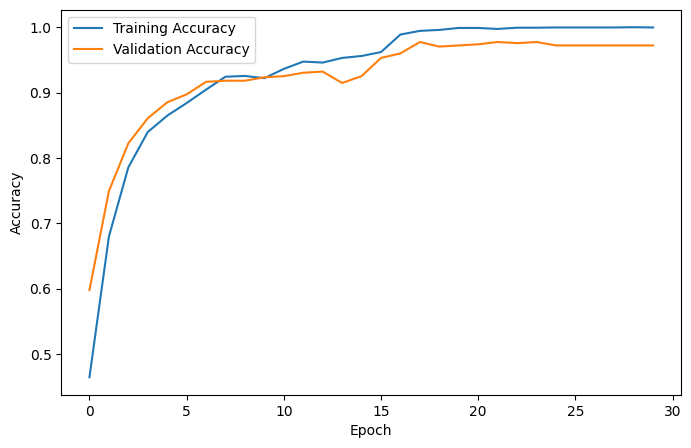

In [27]:
plt.figure(figsize=(8,5))

plt.plot(
    history_frozen.history["accuracy"] +
    history_finetune.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_frozen.history["val_accuracy"] +
    history_finetune.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

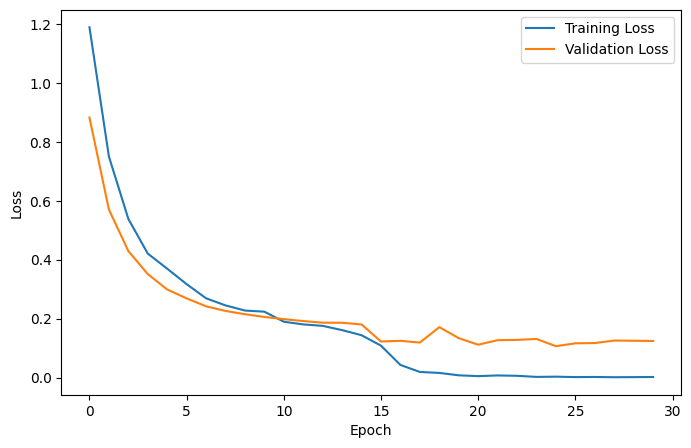

In [28]:
plt.figure(figsize=(8,5))

plt.plot(
    history_frozen.history["loss"] +
    history_finetune.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_frozen.history["val_loss"] +
    history_finetune.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

In [29]:
y_true = []

y_pred = []

for images, labels in test_dataset:

    predictions = model.predict(images)

    predicted_classes = np.argmax(
        predictions,
        axis=1
    )

    actual_classes = np.argmax(
        labels.numpy(),
        axis=1
    )

    y_true.extend(actual_classes)

    y_pred.extend(predicted_classes)

1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step


In [30]:
print(

    classification_report(

        y_true,

        y_pred,

        target_names=class_names

    )

)

               precision    recall  f1-score   support

       Eczema       1.00      0.99      1.00       232
Leishmaniasis       0.97      0.97      0.97       113
        Tinea       0.99      1.00      0.99       228

     accuracy                           0.99       573
    macro avg       0.99      0.99      0.99       573
 weighted avg       0.99      0.99      0.99       573



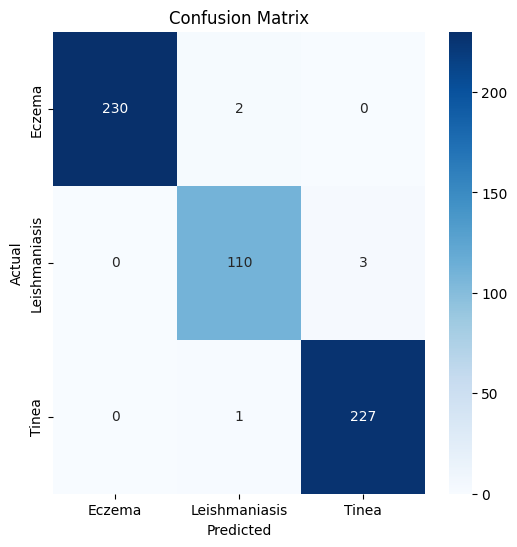

In [31]:
import seaborn as sns

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(6,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [32]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

In [33]:
y_true = []
y_score = []

for images, labels in test_dataset:

    predictions = model.predict(images, verbose=0)

    y_score.extend(predictions)

    y_true.extend(np.argmax(labels.numpy(), axis=1))

y_true = np.array(y_true)
y_score = np.array(y_score)

In [34]:
y_true_bin = label_binarize(
    y_true,
    classes=np.arange(NUM_CLASSES)
)

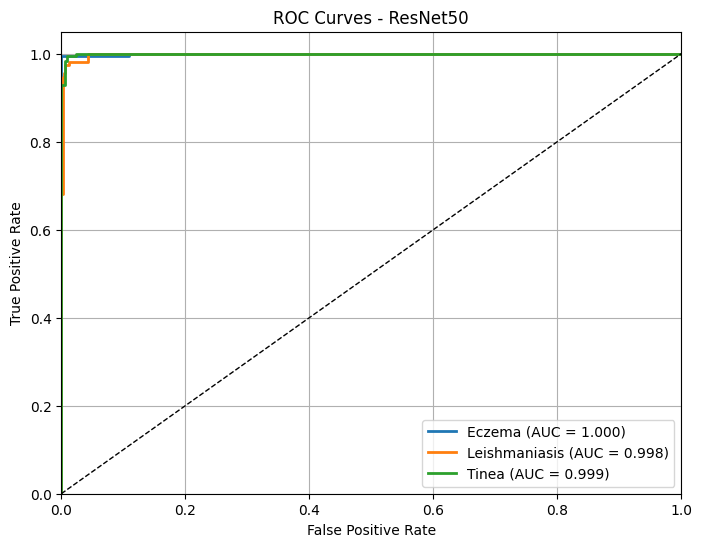

In [36]:
plt.figure(figsize=(8, 6))

for i in range(NUM_CLASSES):

    fpr, tpr, _ = roc_curve(
        y_true_bin[:, i],
        y_score[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{class_names[i]} (AUC = {roc_auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    'k--',
    linewidth=1
)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - ResNet50")

plt.legend(loc="lower right")

plt.grid(True)

plt.show()

In [37]:
print("AUC Scores\n")

for i in range(NUM_CLASSES):

    fpr, tpr, _ = roc_curve(
        y_true_bin[:, i],
        y_score[:, i]
    )

    roc_auc = auc(fpr, tpr)

    print(f"{class_names[i]:15s}: {roc_auc:.4f}")

AUC Scores

Eczema         : 0.9995
Leishmaniasis  : 0.9984
Tinea          : 0.9995


Cohen's Kappa

In [38]:
from sklearn.metrics import cohen_kappa_score

kappa = cohen_kappa_score(y_true, y_pred)

print("="*50)
print(f"Cohen's Kappa Score : {kappa:.4f}")
print("="*50)

Cohen's Kappa Score : 0.9836


Matthews Correlation Coefficient (MCC)

In [39]:
from sklearn.metrics import matthews_corrcoef

mcc = matthews_corrcoef(y_true, y_pred)

print("="*50)
print(f"Matthews Correlation Coefficient : {mcc:.4f}")
print("="*50)

Matthews Correlation Coefficient : 0.9836


Specificity for Each Class

In [40]:
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_true, y_pred)

print("="*50)
print("Specificity")
print("="*50)

for i, class_name in enumerate(class_names):

    TP = cm[i, i]

    FN = np.sum(cm[i, :]) - TP

    FP = np.sum(cm[:, i]) - TP

    TN = np.sum(cm) - (TP + FP + FN)

    specificity = TN / (TN + FP)

    print(f"{class_name:15s}: {specificity:.4f}")

Specificity
Eczema         : 1.0000
Leishmaniasis  : 0.9935
Tinea          : 0.9913


Macro Average Specificity

In [41]:
specificities = []

for i in range(NUM_CLASSES):

    TP = cm[i, i]

    FN = np.sum(cm[i, :]) - TP

    FP = np.sum(cm[:, i]) - TP

    TN = np.sum(cm) - (TP + FP + FN)

    specificity = TN / (TN + FP)

    specificities.append(specificity)

print("="*50)
print(f"Average Specificity : {np.mean(specificities):.4f}")
print("="*50)

Average Specificity : 0.9949


In [43]:
import time

images, labels = next(iter(test_dataset))

sample = images[:1]

start = time.time()

prediction = model.predict(sample, verbose=0)

end = time.time()

print("="*50)
print(f"Inference Time : {(end-start)*1000:.2f} ms")
print("="*50)

Inference Time : 576.18 ms


In [44]:
import os

model_path = os.path.join(
    OUTPUT_DIR,
    "resnet50_final.keras"
)

size = os.path.getsize(model_path)/(1024*1024)

print("="*50)
print(f"Model Size : {size:.2f} MB")
print("="*50)

Model Size : 204.79 MB


In [52]:
from google.colab import files

uploaded = files.upload()

Saving test3.jfif to test3.jfif


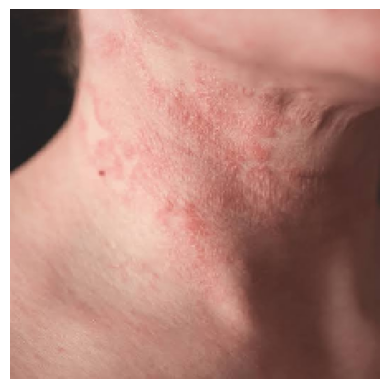

In [53]:
from tensorflow.keras.utils import load_img, img_to_array
import matplotlib.pyplot as plt

image_path = list(uploaded.keys())[0]

img = load_img(image_path, target_size=(224, 224))

plt.imshow(img)
plt.axis("off")
plt.show()

In [54]:
img_array = img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)

img_array = preprocess_input(img_array)

In [55]:
prediction = model.predict(img_array)

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step
[[1.3180657e-02 5.2100833e-04 9.8629826e-01]]


In [56]:
predicted_index = np.argmax(prediction)

predicted_class = class_names[predicted_index]

confidence = prediction[0][predicted_index] * 100

print(f"Predicted Class : {predicted_class}")
print(f"Confidence      : {confidence:.2f}%")

Predicted Class : Tinea
Confidence      : 98.63%


In [57]:
print("Prediction Probabilities\n")

for i, class_name in enumerate(class_names):
    print(f"{class_name:15s}: {prediction[0][i]*100:.2f}%")

Prediction Probabilities

Eczema         : 1.32%
Leishmaniasis  : 0.05%
Tinea          : 98.63%


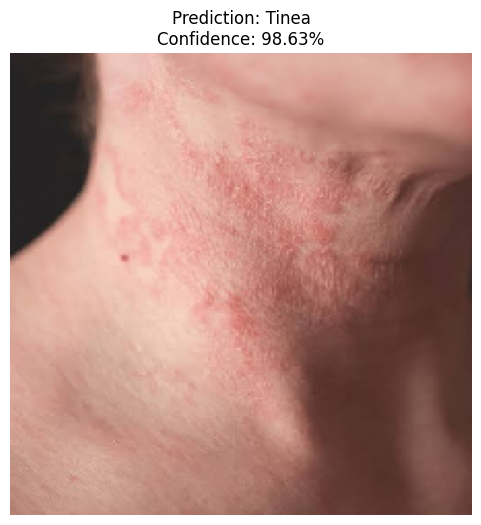

In [58]:
plt.figure(figsize=(6,6))

plt.imshow(img)

plt.title(
    f"Prediction: {predicted_class}\nConfidence: {confidence:.2f}%"
)

plt.axis("off")

plt.show()